# Generating LHC data with CFM Model

#### Background

Simulations for LHC physics is a major computational task at the experiment, and will become more computationally intensive in the coming years, so if ML techniques can speed up some aspects of this then it would be very useful. The process we are studying is Drell-Yan: $pp\rightarrow Z\rightarrow \mu\mu$


#### Outline

- Imports
- Loading the data
- Preprocessing
- Defining the CFM Model
- Training the model
- Study the results


### Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

In [2]:
if torch.cuda.is_available():
    torch.set_default_device("cuda")
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [3]:
print(device)

cpu


### Loading the data

In [4]:
!wget "https://www.dropbox.com/scl/fi/gvmelw7u619moo8nyg3j7/ErUMData.zip?e=1&file_subpath=%2Fdy_trn_data.npy&rlkey=kq4do1fmalppjt2v24lzau4li&st=3umjk6s1&dl=0"
!unzip 'ErUMData.zip?e=1&file_subpath=%2Fdy_trn_data.npy&rlkey=kq4do1fmalppjt2v24lzau4li&st=3umjk6s1&dl=0'

--2026-07-14 10:02:01--  https://www.dropbox.com/scl/fi/gvmelw7u619moo8nyg3j7/ErUMData.zip?e=1&file_subpath=%2Fdy_trn_data.npy&rlkey=kq4do1fmalppjt2v24lzau4li&st=3umjk6s1&dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.80.18, 2620:100:6018:18::a27d:312
Connecting to www.dropbox.com (www.dropbox.com)|162.125.80.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc1422dc63d8cc331dceb7fe6b8b.dl.dropboxusercontent.com/cd/0/inline/DEMVhfsQqPm7iG-qgIsY3sbMZQD62YAkmk7AdMV8aQacH9WarhVj58ixb96NQeODYVE6DUuyGmCsS3AJ_WJn9dZYeS0FTVvu6320xoG-Mk3BEOmDolWRSGVA1D2GFb-AuEc/file# [following]
--2026-07-14 10:02:02--  https://uc1422dc63d8cc331dceb7fe6b8b.dl.dropboxusercontent.com/cd/0/inline/DEMVhfsQqPm7iG-qgIsY3sbMZQD62YAkmk7AdMV8aQacH9WarhVj58ixb96NQeODYVE6DUuyGmCsS3AJ_WJn9dZYeS0FTVvu6320xoG-Mk3BEOmDolWRSGVA1D2GFb-AuEc/file
Resolving uc1422dc63d8cc331dceb7fe6b8b.dl.dropboxusercontent.com (uc1422dc63d8cc331dceb7fe6b8b.dl.dropboxusercontent.com)... 162.125

In [5]:
train_data = np.load("dy_trn_data.npy")
val_data = np.load("dy_val_data.npy")
test_data = np.load("dy_tst_data.npy")

In [6]:
train_data.shape, val_data.shape, test_data.shape

((1384081, 8), (296588, 8), (296588, 8))

Each element of the data has 8 entries, corresponding to the 4-momenta of each muon in the process.

Each entry has the form $[E_1, p_{x,1}, p_{y,1}, p_{z,1}, E_2, p_{x,2}, p_{y,2}, p_{z,2}]$.

### Preprocessing

For data to work well with generative models operating on a Gaussian latent space (a typical choice for diffusion models or normalizing flows), we should avoid sharp edges in the input data. We know that $\phi$ follows a uniform distribution, so we can transform it into something closer to a Gaussian by applying $\text{arctanh}$. We also apply a component-wise normalization step such that the data has a mean of $0$ and a standard deviation of $1$.




**Why do Preprocessing?** \
We reduce the degrees of freedom. We use the original 8 quantities to calculate 4 new quantities.

We can remove 4 degrees of freedom from the data. For the remaining 4 degrees of freedom, we can choose a more suitable representation that takes into account the symmetries of our data:
- $p_T = \sqrt{p_{x,1}^2+p_{y,1}^2}$
- $\eta_1 = \text{arctanh}\left(\frac{p_{z,1}}{\sqrt{p_{x,1}^2+p_{y,1}^2+p_{z,1}^2}}\right)$
- $\eta_2 = \text{arctanh}\left(\frac{p_{z,2}}{\sqrt{p_{x,2}^2+p_{y,2}^2+p_{z,2}^2}}\right)$
- $\phi = \text{arctan2}(p_{y,1}, p_{x,1})$

In [14]:
def apply_preprocessing(data_full):
    pt = np.sqrt(data_full[...,1]**2 + data_full[...,2]**2)
    eta1 = np.arctanh(data_full[...,3] / np.sqrt(data_full[...,1]**2 + data_full[...,2]**2 + data_full[...,3]**2))
    eta2 = np.arctanh(data_full[...,7] / np.sqrt(data_full[...,5]**2 + data_full[...,6]**2 + data_full[...,7]**2))
    phi1 = np.arctanh(np.arctan2(data_full[...,2], data_full[...,1]) / np.pi)
    return np.stack((pt, eta1, eta2, phi1), axis=-1)

**Why do Invert Preprocessing?** \
Once the CFM model generates new, fake data (which will be in that standardized 4-feature format), this function reverses the math to reconstruct the full 8-number 4-momenta so you can do actual physics analysis on it.
* Reconstructing Kinematics: It un-squashes $\phi_1$, then uses standard trigonometry ($p_x = p_T \cos\phi$) to get the $x$ and $y$ vectors. It uses the inverse of pseudorapidity ($p_z = p_T \sinh\eta$) to get the $z$-axis momentum.

* The "Physicist's Assumption" (A great talking point): Look closely at these lines:
  * px2 = -px1
  * py2 = -py1
  * This is a massive physical simplification. The code is assuming the two muons are perfectly back-to-back in the transverse plane, meaning the original $Z$ boson had exactly zero transverse momentum ($p_T = 0$). It also assumes the muons are massless ($E = \sqrt{p_x^2 + p_y^2 + p_z^2}$). For a simple ML tutorial, this drastically reduces the complexity the neural network has to learn.

*Without **invert_preprocessing**, the AI's output remains a mathematical abstraction rather than usable physical kinematics.*

1. Azimuthal Angle Un-scaling \
  The normalized angle feature ($\tilde{\phi}_1$) is transformed back into its physical radian value ($\phi_1$):$$\phi_1 = \arctan(\tilde{\phi}_1) \cdot \pi$$
2. Muon 1 Kinematics \
  Using standard particle physics trigonometry, the 3-momentum ($p_x, p_y, p_z$) and Energy ($E$) are reconstructed for the first muon. Note that this assumes the muon is massless ($E = \vert{}p\vert{}$):$$p_{x,1} = p_T \cos(\phi_1)$$$$p_{y,1} = p_T \sin(\phi_1)$$$$p_{z,1} = p_T \sinh(\eta_1)$$$$E_1 = \sqrt{p_{x,1}^2 + p_{y,1}^2 + p_{z,1}^2}$$
3. Muon 2 Kinematics (Transverse Balance) \
  The transverse momentum for the second muon is perfectly inverted to force a $Z$ boson $p_T$ of zero, while its $z$-axis momentum is calculated independently using its own pseudorapidity ($\eta_2$):$$p_{x,2} = -p_{x,1}$$$$p_{y,2} = -p_{y,1}$$$$p_{z,2} = p_T \sinh(\eta_2)$$$$E_2 = \sqrt{p_{x,2}^2 + p_{y,2}^2 + p_{z,2}^2}$$
4. Final Output \
  The function recombines these values into the standard 8-dimensional array representing the 4-momenta of both particles:$$\mathbf{P}_{event} = (E_1, p_{x,1}, p_{y,1}, p_{z,1}, E_2, p_{x,2}, p_{y,2}, p_{z,2})$$

**EXERCISE 1**

In [15]:
def invert_preprocessing(data_red):
    pt = data_red[...,0]
    eta1 = data_red[...,1]
    eta2 = data_red[...,2]
    phi1 = np.arctan(data_red[...,3]) * np.pi

    # TODO: Write formulas to find all 8 parameters of both Muons (Make sure the variables match with the return statement of the function below)




    return np.stack((e1, px1, py1, pz1, e2, px2, py2, pz2), axis=-1)

Now we can apply them to the training data and create a torch Dataset and DataLoader:

The normalization is done according to:
$$Z = \frac{X - \mu}{\sigma}$$

Why do we do this?

Neural networks are highly sensitive to the scale of input numbers. If your transverse momentum ($p_T$) has values around $40.0$ but your pseudorapidity ($\eta$) has values around $1.5$, the neural network will naturally assume the larger numbers are "more important" and will struggle to learn the vector field accurately.

**EXERCISE 2**

In [16]:
# TODO: Apply Preprocessing fucntion to the Train Data

train_mean = np.mean(train_data_preproc, axis=0)      # Mean of the Preproc Train Data
train_std = np.std(train_data_preproc, axis=0)        # Standard deviation of Mean of the Preproc Train Data

#TODO: Apply Normalization Formula
train_data_normalized = torch.tensor( , dtype=torch.float32)

train_dataset = TensorDataset(train_data_normalized)
train_dataloader = DataLoader(train_data_normalized, batch_size=10000, shuffle=True, generator=torch.Generator(device))

In [17]:
train_data_normalized.shape

torch.Size([1384081, 4])

Here is the plot of data before Z score normalization:

/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


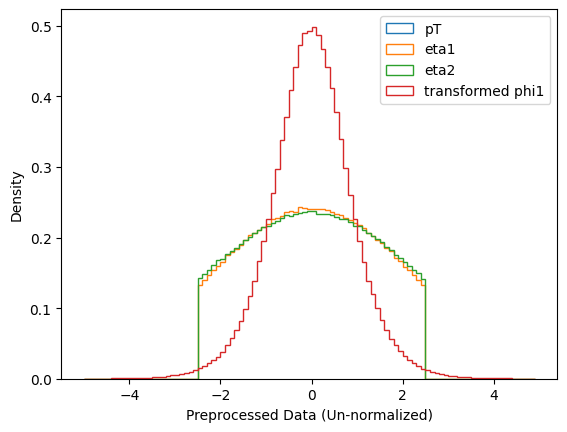

In [18]:
import numpy as np
import matplotlib.pyplot as plt

fig, axs = plt.subplots()

bins = np.arange(-5, 5, step=0.1)

# Using descriptive labels for the legend
feature_names = ["pT", "eta1", "eta2", "transformed phi1"]
for i in range(4):
    axs.hist(
        train_data_preproc[:, i].cpu().numpy(),
        density=True,
        bins=bins,
        label=feature_names[i],
        histtype="step"
    )
axs.set_xlabel("Preprocessed Data (Un-normalized)")
axs.set_ylabel("Density")
axs.legend()
plt.show()

Here is the plot of 4 degrees of freedom after normalization:

**EXERCISE 3**

In [ ]:
#TODO: Plot the graph of Normalized Data

#### Conditional Flow Matching

In principle one can categorize Conditional Flow Matching (CFM) models as a specific kind of diffusion model. The idea here is to see the diffusion as a continous process. At time $t=0$ we are in our physical phase space and at time $t=1$ we are in our Gaussian latent space. The process is goverend by a vector field
\begin{align}
\frac{dx}{dt} = u(x,t)
\end{align}

here $x_0$ is the data point from real
and its inital condition.
In principle we could learn this vector field as a regression task using a MSE loss. However, how can we define it? We start by describing the Flow model by a linear trajectory
\begin{align}
x(t, x_0, x_1) = (1-t)x_0 + tx_1
\end{align}
with $x_0 \sim p(x_0)$ and $x_1 \sim \mathcal{N}(0,1)$ for at any time t.
The corresponding vector field yields
\begin{align}
v(x,t, x_0, x_1) = x_1 - x_0.
\end{align}
Why is this useful? We want to generate $x_0$, why are we interested in learning a quantitiy, which is only defined once $x_0$ is known? Well luckily, it can be shown that
\begin{align}
\mathrm{argmin}_\theta \left< (v_\theta(x_t,t) - v(x,t))^2\right>_{x,t \sim p(x,t)}
\end{align}
where $v_\theta(x_t,t)$ is the network output. Hence, we have all ingredients to cook a tractable loss function. Once we are finished training we can simply solve
\begin{align}
x_0 = x_1 - \int_0^1 v_\theta (x,t) d_t
\end{align}
using a fast ODE-sampler.

What is the network input? How many dimensions has the input?


Implement the CFM model loss function using the following steps:
1. Randomly draw the timestep $t$ from a uniform distribution.
2. Sample Gaussian noise.
3. Compute $x_t$ using the function above.
4. Call the network as a function of $x_t$ and $t$.
5. Compute the MSE loss.

In [20]:
!pip install torchdiffeq

In [21]:
# use ode solver that can operate on gpu
from torchdiffeq import odeint

class CFM(nn.Module):
    def __init__(        # ARCHITECTURE
        self,
        data_dim: int,     # number of features in the data
        hidden_dim: int,   # number of hidden layer nodes
    ):
        super().__init__()
        self.data_dim = data_dim

        # Network input: [t, x_t] → data_dim + 1 inputs, data_dim outputs
        self.net = nn.Sequential(
            nn.Linear(data_dim + 1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, data_dim),
        )

    def batch_loss(      # LEARNING PHASE
        self,
        x: torch.Tensor, # input data, shape (n_batch, data_dim)
    ) -> torch.Tensor:   # loss, shape (n_batch, )
        n_batch = x.shape[0]

        # 1. Sample t ~ Uniform(0, 1), shape (n_batch, 1)
        t = torch.rand(n_batch, 1, device=x.device, dtype=x.dtype)   # Random Time

        # 2. Sample x_1 ~ N(0, 1)
        x_1 = torch.randn_like(x) # Noise Generation

        # 3. Interpolate: x_t = (1 - t) * x_0 + t * x_1
        x_t = (1 - t) * x + t * x_1

        # 4. Predict vector field v_θ(x_t, t)
        v_pred = self.net(torch.cat([t, x_t], dim=1))

        # 5. Target vector: v = x_1 - x_0
        v_target = x_1 - x

        # MSE loss averaged over batch
        return F.mse_loss(v_pred, v_target)

    def sample(        # GENERATION PHASE
        self,
        n_samples: int,        # number of samples
    ) -> torch.Tensor:         # sampled data, shape (n_samples, data_dim) or (n_steps, n_samples, data_dim)
        dtype = torch.float32
        x_1 = torch.randn(n_samples, self.data_dim, device=device, dtype=dtype)   # Random Gaussian Noise

        def net_wrapper(t, x_t):
            t = t * torch.ones_like(x_t[:, [0]], dtype=dtype, device=device)
            nn_out = self.net(torch.cat([t, x_t], dim=1))
            return nn_out

        x_t = odeint(net_wrapper,
                     x_1,
                     torch.tensor([1., 0.], dtype=dtype, device=device)
                     )

        return x_t[-1]

Repeat training and sampling with a CFM.

In [22]:
cfm = CFM(
    data_dim = 4,
    hidden_dim = 64,
)
epochs = 50

optimizer = torch.optim.Adam(cfm.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-2, steps_per_epoch=len(train_dataloader), epochs=epochs)

losses = np.zeros(epochs)
for epoch in range(epochs):
    epoch_losses = []
    for batch, x in enumerate(train_dataloader):
        loss = cfm.batch_loss(x)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()
        epoch_losses.append(loss.item())
    epoch_loss = np.mean(epoch_losses)
    print(f"Epoch {epoch+1}: loss = {epoch_loss}")
    losses[epoch] = epoch_loss

Epoch 1: loss = 1.883537117525828
Epoch 2: loss = 1.5446623572342688
Epoch 3: loss = 1.4602645335437583
Epoch 4: loss = 1.4417917548323707
Epoch 5: loss = 1.4372512436599183
Epoch 6: loss = 1.4321891669746782
Epoch 7: loss = 1.4311257274888403
Epoch 8: loss = 1.4310354054402963
Epoch 9: loss = 1.4297149918919845
Epoch 10: loss = 1.4273759992860204
Epoch 11: loss = 1.4284555423173972
Epoch 12: loss = 1.4267893900974191
Epoch 13: loss = 1.4271514021235405
Epoch 14: loss = 1.4260975645600462
Epoch 15: loss = 1.4248105021689434
Epoch 16: loss = 1.4248875997049346
Epoch 17: loss = 1.425469439664333
Epoch 18: loss = 1.4246081980012304
Epoch 19: loss = 1.4237128521898668
Epoch 20: loss = 1.4226368700000023
Epoch 21: loss = 1.4232560327584796
Epoch 22: loss = 1.4223478243505354
Epoch 23: loss = 1.4242736907314053
Epoch 24: loss = 1.4222904658146043
Epoch 25: loss = 1.422796117316047
Epoch 26: loss = 1.423576880702012
Epoch 27: loss = 1.4225549955162213
Epoch 28: loss = 1.424644076566902
Epoch 

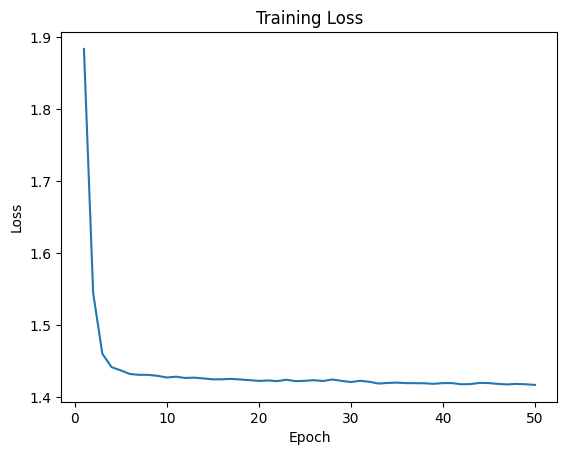

In [23]:
# Plot epochs vs losses
fig, axs = plt.subplots()
axs.plot(range(1, epochs + 1), losses)
axs.set_xlabel("Epoch")
axs.set_ylabel("Loss")
axs.set_title("Training Loss")
plt.show()


**EXERCISE 4**

In [24]:
with torch.no_grad():
    sample = cfm.sample(10000).cpu().numpy()

# TODO: Use the Invert_Preprocessing function here
# multiply it by train_std, and add train_mean to un-normalize it


gen_event_im, _, gen_pt, _ = get_obs(sample_pp)

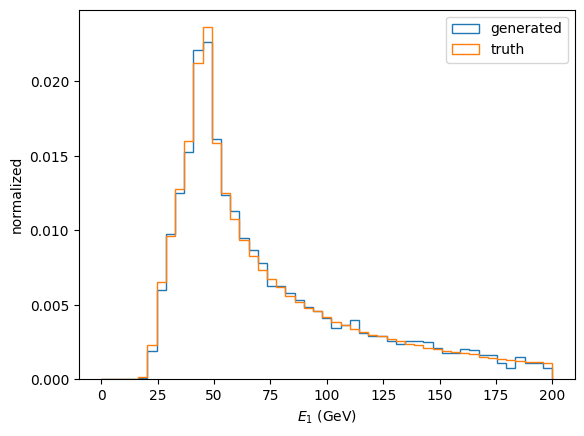

In [25]:
fig, axs = plt.subplots()

bins = np.linspace(0,200,50)
axs.hist(sample_pp[:,0], bins=bins, density=True, histtype="step", label="generated")
axs.hist(test_data[:,0], bins=bins, density=True, histtype="step", label="truth")  # Test Data

axs.set_xlabel("$E_1$ (GeV)")
axs.set_ylabel("normalized")
axs.legend()
plt.show()

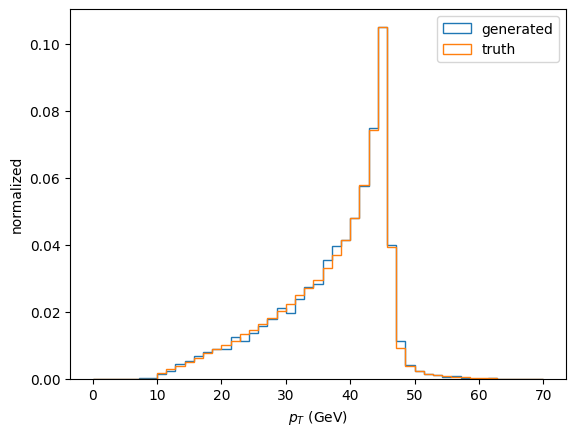

In [26]:
fig, axs = plt.subplots()

bins = np.linspace(0, 70, 50)
axs.hist(gen_pt, bins=bins, density=True, histtype="step", label="generated")
axs.hist(test_muon1_pts, bins=bins, density=True, histtype="step", label="truth")

axs.set_xlabel("$p_T$ (GeV)")
axs.set_ylabel("normalized")
axs.legend()
plt.show()

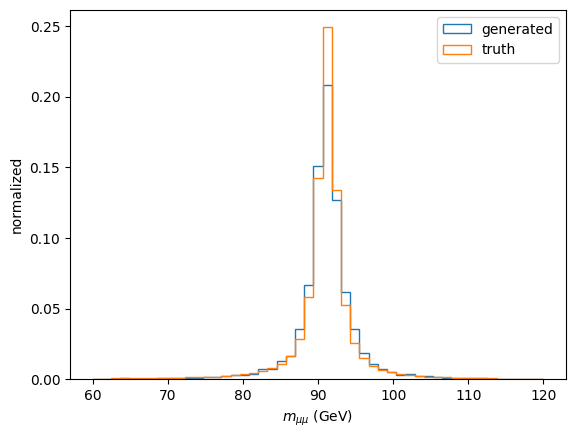

In [27]:
fig, axs = plt.subplots()

bins = np.linspace(60, 120, 50)
axs.hist(gen_event_im, bins=bins, density=True, histtype="step", label="generated")
axs.hist(test_event_ims, bins=bins, density=True, histtype="step", label="truth")

axs.set_xlabel(r"$m_{\mu\mu}$ (GeV)")
axs.set_ylabel("normalized")
axs.legend()
plt.show()

Prepared by: SYED ALI ASGHAR